# Shor's Period-Finding Benchmark – Tutorial

This notebook walks through how to:

1. Build a ShorPeriodFindingBenchmark
2. Generate benchmark circuits
3. Attach results
4. Evaluate the experimental results

In [1]:
from frontier import ShorPeriodFindingBenchmark

## Create benchmark

A benchmark instance can be created simply by defining the required parameters for running a benchmark experiment and initializing the benchmark object.

Parameters:
- `number_of_qubits`: number of qubits in the target register (without the control register).
- `sample_ids`: a list of integers labelling the randomly generated primitive polynomials. For a given `sample_id`, the generated primitive polynomial — and therefore the corresponding circuit — is deterministic. For the `ShorPeriodFindingBenchmark`, only a single circuit needs to be generated for a given problem size, so `len(sample_ids) = 1`.
- `shots`: number of measurement shots per circuit (specified by the benchmark description).

In [2]:
n_qubits = 3
sample_ids = [1]
shots = 10**4

benchmark = ShorPeriodFindingBenchmark(
    number_of_qubits=n_qubits,
    sample_ids=sample_ids,
    shots=shots,
    format="qasm2",
    target_sdk="qiskit",
    control_register_offset=1,  # control_register_size = 2*number_of_qubits + offset
    auto_save=False,
    workdir="tutorial_data",
)

You can then generate the benchmark circuits by calling the corresponding method.

In [3]:
benchmark.create_benchmark()

benchmark  # print the main properties of the benchmark instance

ShorPeriodFindingBenchmark(
  benchmark_id='shor_period_finding_nq3_s1_20260723T180832_6d0df986',
  number_of_qubits=3,
  sample_size=1,
  format='qasm2',
  target_sdk='qiskit',
  workdir=WindowsPath('tutorial_data'),
)

You can easily access any of the characteristics of the benchmark protocol or the corresponding circuits, such as:
- the ID of the benchmark (`benchmark.benchmark_id`)
- benchmark metadata (`benchmark.benchmark_metadata`)
- default directory used to save the benchmark instance (`benchmark.DEFAULT_WORKDIR`)
- emitter options used to generate circuits (`benchmark.emitter_options`)
- circuit representation format (`benchmark.format`)
- number of measurement schemes per sample (`benchmark.number_of_measurements`)
- number of qubits used in the benchmark (`benchmark.number_of_qubits`)
- number of samples in the benchmark (`benchmark.sample_size`)
- the control register size and offset (`benchmark.control_register_size`, `benchmark.control_register_offset`)
- target SDK used for circuit generation (`benchmark.target_sdk`)
- etc.

In [4]:
print("benchmark.benchmark_id:", benchmark.benchmark_id)
print("benchmark.benchmark_metadata:", benchmark.benchmark_metadata)
print("benchmark.DEFAULT_WORKDIR:", benchmark.DEFAULT_WORKDIR)
print("benchmark.emitter_options:", benchmark.emitter_options)
print("benchmark.format:", benchmark.format)
print("benchmark.number_of_measurements:", benchmark.number_of_measurements)
print("benchmark.number_of_qubits:", benchmark.number_of_qubits)
print("benchmark.sample_size:", benchmark.sample_size)
print("benchmark.control_register_size:", benchmark.control_register_size)
print("benchmark.control_register_offset:", benchmark.control_register_offset)
print("benchmark.target_sdk:", benchmark.target_sdk)

benchmark.benchmark_id: shor_period_finding_nq3_s1_20260723T180832_6d0df986
benchmark.benchmark_metadata: {}
benchmark.DEFAULT_WORKDIR: .benchmarks
benchmark.emitter_options: QasmEmitterOptions(format='qasm2', target_sdk='qiskit', includes=('qelib1.inc',), float_precision=6, custom_template=None, map={'x': 'x', 'y': 'y', 'z': 'z', 'h': 'h', 's': 's', 'sdg': 'sdg', 't': 't', 'u': 'u3', 'cx': 'cx', 'cy': 'cy', 'cz': 'cz', 'swap': 'swap', 'rx': 'rx', 'ry': 'ry', 'rz': 'rz', 'measure': 'measure'})
benchmark.format: qasm2
benchmark.number_of_measurements: 1
benchmark.number_of_qubits: 3
benchmark.sample_size: 1
benchmark.control_register_size: 7
benchmark.control_register_offset: 1
benchmark.target_sdk: qiskit


---

You can retrieve the generated samples as a collection of all benchmark circuits for a given experiment. Each sample represents a single logical unitary (or base circuit); for the Shor period-finding benchmark there is exactly one circuit per sample.

`benchmark.samples` is a list of samples, where each sample corresponds to one complete experiment. For this benchmark, a single sample is generated per `sample_id`.

Each sample is represented as a dictionary containing:
- `sample_id`: a unique identifier for the sample.
- `sample_metadata`: metadata associated with the sample.
- `circuits`: a list of concrete circuits (a single QPE circuit here).

The `sample_metadata` field is a structured dictionary that contains the following entries:
- `type`: the benchmark type (`"shor_period_finding"`).
- `number_of_target_qubits`: the number of qubits in the target register.
- `control_register_size`: the number of qubits in the control (phase-estimation) register.
- `control_register_offset`: the additive offset in `control_register_size = 2 * number_of_target_qubits + control_register_offset`.
- `primitive_polynomial`: the primitive polynomial over GF(2) (encoded as an integer bitmask) defining the maximum-cycle linear permutation.
- `companion_matrix`: the companion matrix of that polynomial, i.e. the linear permutation applied to the target register.

Each element of `circuits` is itself a dictionary with the following fields:
- `circuit_id`: a unique identifier for the circuit.
- `observable`: the measured observable (`None` here, since the benchmark measures in the computational basis).
- `qasm`: the QASM code for the corresponding quantum circuit.
- `metadata`: circuit-level metadata describing the role or type of the circuit.

In [5]:
# Print properties of the first sample
sample = benchmark.samples[0]

print("sample_id:", sample.get("sample_id"))

# Extract sample metadata
sample_metadata = sample.get("sample_metadata", {})

print("type:", sample_metadata.get("type"))
print("number_of_target_qubits:", sample_metadata.get("number_of_target_qubits"))
print("control_register_size:", sample_metadata.get("control_register_size"))
print("control_register_offset:", sample_metadata.get("control_register_offset"))
print("primitive_polynomial:", sample_metadata.get("primitive_polynomial"),
      "=", bin(sample_metadata.get("primitive_polynomial")))
print("companion_matrix:\n", sample_metadata.get("companion_matrix"))

# Print circuits
print("\ncircuits:")
circuits = sample.get("circuits", [])

# Print the first circuit (if it exists)
circuit = circuits[0]
print("circuit_id:", circuit.get("circuit_id"), "\n")
print("observable:", circuit.get("observable"), "\n")
print("qasm:", circuit.get("qasm"), "\n")
print("metadata:", circuit.get("metadata"), "\n")

sample_id: 1
type: shor_period_finding
number_of_target_qubits: 3
control_register_size: 7
control_register_offset: 1
primitive_polynomial: 13 = 0b1101
companion_matrix:
 [[0 1 0]
 [0 0 1]
 [1 0 1]]

circuits:
circuit_id: 1_qpe 

observable: None 

qasm: OPENQASM 2.0;

include "qelib1.inc";

qreg q[10];
creg c[7];

h q[0];
h q[1];
h q[2];
h q[3];
h q[4];
h q[5];
h q[6];
x q[7];
h q[8];
cx q[9], q[8];
rz(-0.785398) q[8];
cx q[0], q[8];
rz(0.785398) q[8];
cx q[9], q[8];
rz(-0.785398) q[8];
cx q[0], q[8];
rz(0.785398) q[9];
rz(0.785398) q[8];
h q[8];
cx q[0], q[9];
rz(0.785398) q[0];
rz(-0.785398) q[9];
cx q[0], q[9];
h q[7];
cx q[8], q[7];
rz(-0.785398) q[7];
cx q[0], q[7];
rz(0.785398) q[7];
cx q[8], q[7];
rz(-0.785398) q[7];
cx q[0], q[7];
rz(0.785398) q[8];
rz(0.785398) q[7];
h q[7];
cx q[0], q[8];
rz(0.785398) q[0];
rz(-0.785398) q[8];
cx q[0], q[8];
h q[9];
cx q[8], q[9];
rz(-0.785398) q[9];
cx q[0], q[9];
rz(0.785398) q[9];
cx q[8], q[9];
rz(-0.785398) q[9];
cx q[0], q[9];
rz(0.785

## Perform noisy simulation with qiskit
### Load a circuit into Qiskit

The benchmark's shipped artifact for each circuit is its emitted OpenQASM 2 string,
so to run it on a backend we load that QASM into a Qiskit circuit.

Two emitter details make the round-trip work:
- the circuit is emitted with `target_sdk="qiskit"`, so the QASM includes
  `qelib1.inc` (defining standard gates like `h`);
- Qiskit's strict OpenQASM 2 parser needs `qasm2.LEGACY_CUSTOM_INSTRUCTIONS` to
  accept legacy gates such as `swap`.

In [6]:
from qiskit import qasm2

# The benchmark was already generated above; grab the emitted QASM of its circuit.
qasm = benchmark.samples[0]["circuits"][0]["qasm"]

# Load the emitted OpenQASM 2 into a runnable Qiskit circuit.
qiskit_circuit = qasm2.loads(qasm, custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS)

print(f"{qiskit_circuit.num_qubits} qubits, {qiskit_circuit.num_clbits} classical bits")
print("gate counts:", dict(qiskit_circuit.count_ops()))

# For a graphical drawing use qiskit_circuit.draw("mpl")
qiskit_circuit

10 qubits, 7 classical bits
gate counts: {'rz': 329, 'cx': 270, 'h': 90, 'measure': 7, 'swap': 3, 'x': 1}


### Noisy simulation

In [7]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, pauli_error

In [8]:
def noise_model(p_1q, p_2q, p_r):
    nm = NoiseModel()

    # basis gates
    one_qubit_gates = ['u3']
    two_qubit_gates = ['cx']
    basis_gates = ['cx', 'u3']

    # 1-qubit depolarizing error on all 1-qubit gates you use
    error_1q = depolarizing_error(p_1q, 1)
    nm.add_all_qubit_quantum_error(error_1q, one_qubit_gates)
    
    # 2-qubit depolarizing error on all 2-qubit gates (here only cx)
    error_2q = depolarizing_error(p_2q, 2)
    nm.add_all_qubit_quantum_error(error_2q, two_qubit_gates)
    
    # measurement readout error: simple bit-flip on outcome
    meas_error = pauli_error([('X', p_r), ('I', 1 - p_r)])
    nm.add_all_qubit_quantum_error(meas_error, ['measure'])

    return nm

We run each benchmark circuit on a noisy Aer backend. To match the noise model's gate labels (`u3`, `cx`), the emitted circuit is transpiled to the `["cx", "u3"]` basis — every single-qubit gate becomes a `u3`, and every two-qubit gate (including `swap`) becomes a `cx`. This is why the copied `noise_model` works unchanged despite the emitter's native gate set (`rz`, `h`, `x`, `swap`, …).

Following the requested setup:
- **single-qubit gates are perfect** (`p_1q = 0`);
- the **CNOT and measurement** error rates are swept over `[1e-3, 1e-4, 1e-5]` (the same value `p` is used for both `p_2q` and `p_r`);
- we simulate for target-register sizes `n = 2, 3, 4, 5`.

Each run is scored with the benchmark's own `evaluate_benchmark`, and we report the **success ratio** `η = P_success / (φ(2ⁿ−1) / (2ⁿ−1))` — the measured success probability normalized by the ideal perfect-gate ceiling `φ(r)/r`.

In [9]:
import numpy as np
from qiskit import transpile
from frontier.shorbenchmark._mersenne_factors import mersenne_prime_factors

basis_gates = ["cx", "u3"]  # single-qubit gates -> u3, two-qubit gates (incl. swap) -> cx


def euler_phi_mersenne(n):
    """phi(2**n - 1), computed from the benchmark's distinct-prime-factor table."""
    r = (1 << n) - 1
    phi = r
    for prime in mersenne_prime_factors(n):
        phi = phi // prime * (prime - 1)
    return phi


def noisy_success_ratio(n, backend, shots=2000, sample_id=1, control_register_offset=1):
    """Simulate the benchmark's circuit for `n` target qubits on `backend` and
    return the success ratio eta = P_success / (phi(r) / r)."""
    bench = ShorPeriodFindingBenchmark(
        number_of_qubits=n,
        sample_ids=[sample_id],
        shots=shots,
        control_register_offset=control_register_offset,
        format="qasm2",
        target_sdk="qiskit",
        auto_save=False,
        workdir="tutorial_data",
    )
    bench.create_benchmark()
    circuit_entry = bench.samples[0]["circuits"][0]

    # Load the emitted QASM and transpile it to the noise model's {cx, u3} basis.
    qc = qasm2.loads(circuit_entry["qasm"], custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS)
    counts = backend.run(transpile(qc, backend), shots=shots).result().get_counts()

    # Score the noisy counts with the benchmark's own evaluator.
    bench.add_experimental_results(
        {circuit_entry["circuit_id"]: counts}, platform="aer-noisy", auto_save=False
    )
    p_success = bench.evaluate_benchmark(auto_save=False)["results"][str(sample_id)][
        "success_probability"
    ]

    r = (1 << n) - 1
    return p_success / (euler_phi_mersenne(n) / r)

In [10]:
from qiskit_aer import AerSimulator

p_1q = 0                       # single-qubit gates are perfect
p_vals = [1e-3, 1e-4, 1e-5]    # CNOT and measurement error rates to sweep
nvals = np.arange(2, 6)        # target-register sizes n = 2, 3, 4, 5
shots = 2000                   # reduced from 10**4 to keep the n=5 (16-qubit) noisy runs tractable

success_ratios = []
for p in p_vals:
    noisy_backend = AerSimulator(noise_model=noise_model(p_1q, p, p), basis_gates=basis_gates)
    row = [noisy_success_ratio(int(n), noisy_backend, shots=shots) for n in nvals]
    success_ratios.append(row)
    print(f"p = {p:.0e}:", [round(x, 3) for x in row])

success_ratios = np.array(success_ratios)

p = 1e-03: [0.892, 0.82, 0.775, 0.538]


p = 1e-04: [0.908, 0.912, 0.947, 0.879]


p = 1e-05: [0.915, 0.913, 0.94, 0.938]


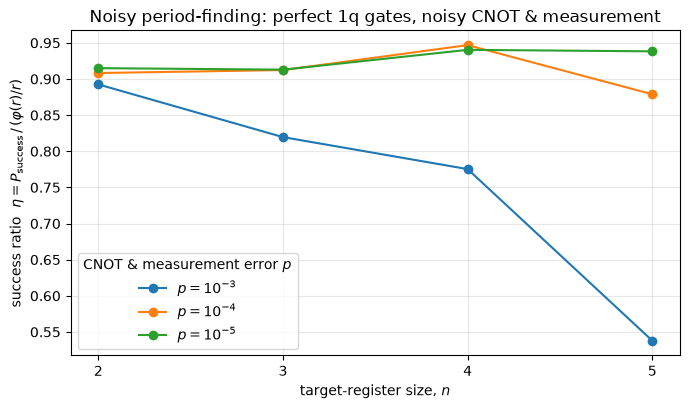

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.2))
for row, p in zip(success_ratios, p_vals):
    ax.plot(nvals, row, "o-", label=fr"$p = 10^{{{int(round(np.log10(p)))}}}$")

ax.set_xticks(nvals)
ax.set_xlabel(r"target-register size, $n$")
ax.set_ylabel(r"success ratio  $\eta = P_\mathrm{success} \,/\, (\varphi(r)/r)$")
ax.set_title("Noisy period-finding: perfect 1q gates, noisy CNOT & measurement")
ax.grid(True, alpha=0.3)
ax.legend(title=r"CNOT & measurement error $p$")
plt.tight_layout()
plt.show()